# Sample Experiment Datamodule Demo

This notebook shows how to:
- load the default UAI `flow-pk-generate` meta-study configuration,
- instantiate an `AICMECompartmentsDataModule`,
- inspect one batch from the dataloader, and
- call `generate_synthetic_study_experiment_list(...)` in all supported modes:
  - `repeated_dosing`
  - `dosing_list` with `dosing_from_samples`
  - `dosing_list` with `dosing_from_range`
  - `diverse_dosing`

The notebook uses the existing `StudyJSON` and `AICMECompartmentsDataBatch` plotting utilities from the repo.


In [2]:
from __future__ import annotations

import sys
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import torch

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / "pff").exists():
    for candidate in [PROJECT_DIR, *PROJECT_DIR.parents]:
        if (candidate / "pff").exists() and (candidate / "config_files").exists():
            PROJECT_DIR = candidate
            break

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from pff import config_dir
from pff.config_classes.data_config import (
    MetaDosingConfig,
    MetaStudyConfig,
    ObservationsConfig,
)
from pff.config_classes.node_pk_config import NodePKExperimentConfig
from pff.data.datasets.aicme_datasets import AICMECompartmentsDataModule
from pff.utils.plots.databatch_plot import (
    plot_list_aicme_databatch,
    plot_list_list_study_json,
    plot_study_json_with_prediction,
    plot_study_json_with_dosing_histograms
)

torch.manual_seed(7)

In [4]:
# Default configuration paths -------------------------------------------------
EXPERIMENT_DIR = config_dir / "experiment_configs" / "UAI" / "Submission" / "flow-pk-generate"
META_STUDY_CONFIG_PATH = EXPERIMENT_DIR / "base.meta_study.yaml"
DOSING_CONFIG_PATH = EXPERIMENT_DIR / "base.dosing.yaml"
OBSERVATIONS_CONFIG_PATH = EXPERIMENT_DIR / "base.observations.yaml"

meta_study_config = MetaStudyConfig.from_yaml(META_STUDY_CONFIG_PATH)
meta_dosing_config = MetaDosingConfig.from_yaml(DOSING_CONFIG_PATH)
context_observations = ObservationsConfig.from_yaml(
    OBSERVATIONS_CONFIG_PATH,
    section="context_observations",
)
target_observations = ObservationsConfig.from_yaml(
    OBSERVATIONS_CONFIG_PATH,
    section="target_observations",
)

cfg = NodePKExperimentConfig(
    meta_study=meta_study_config,
    dosing=meta_dosing_config,
    context_observations=context_observations,
    target_observations=target_observations,
)

# Notebook-friendly runtime knobs.
cfg.train.num_workers = 0
cfg.train.persistent_workers = False
cfg.train.batch_size = 2
cfg.mix_data.n_of_permutations = 1
cfg.mix_data.train_size = 4
cfg.mix_data.val_size = 2
cfg.mix_data.test_size = 2

dm = AICMECompartmentsDataModule(cfg)
dm.prepare_data()

print("Meta-study config loaded from:")
print(META_STUDY_CONFIG_PATH)
print()
print("Meta-study summary:")
pprint({
    "drug_id_options": meta_study_config.drug_id_options,
    "num_individuals_range": meta_study_config.num_individuals_range,
    "time_start": meta_study_config.time_start,
    "time_stop": meta_study_config.time_stop,
    "time_num_steps": meta_study_config.time_num_steps,
    "solver_method": meta_study_config.solver_method,
})


Meta-study config loaded from:
/home/cesarali/Pharma/pff/config_files/experiment_configs/UAI/Submission/flow-pk-generate/base.meta_study.yaml

Meta-study summary:
{'drug_id_options': ['Drug_A', 'Drug_B', 'Drug_C'],
 'num_individuals_range': [5, 10],
 'solver_method': 'rk4',
 'time_num_steps': 100,
 'time_start': 0.0,
 'time_stop': 16.0}


# Repeated Dosing

Returned 2 study for repeated_dosing
{'dosing_mode': 'repeated_dosing',
 'dosing_realization_index': '0',
 'study_name': 'sample_experiment_Drug_C_repeated_dosing_0',
 'substance_name': 'Drug_C'}


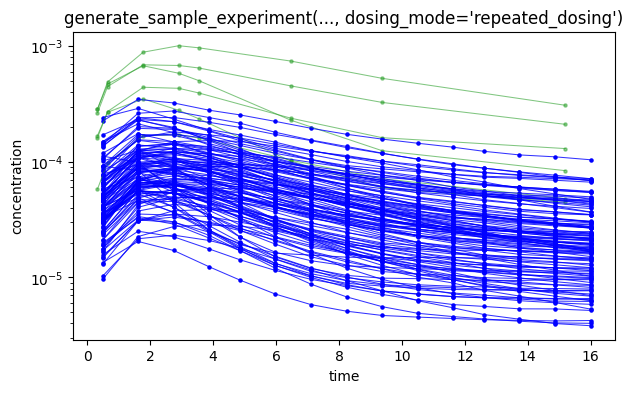

In [5]:
%matplotlib inline
# Sample experiment: repeated_dosing ------------------------------------------
N_TARGETS = 120
N_DOSINGS = 2

repeated_dosing_studies = dm.generate_synthetic_study_experiment_list(
    n_targets=N_TARGETS,
    n_dosings=N_DOSINGS,
    dosing_mode="repeated_dosing",
)

print(f"Returned {len(repeated_dosing_studies)} study for repeated_dosing")
pprint(repeated_dosing_studies[0]["meta_data"])

fig, ax = plt.subplots(figsize=(7, 4))
_ = plot_study_json_with_prediction(
    repeated_dosing_studies[0],
    ax=ax,
    log_scale=True,
)
ax.set_title("generate_sample_experiment(..., dosing_mode='repeated_dosing')")
plt.show()


In [1]:
#repeated_dosing_studies[0]["target"]

# Dosing List

Returned 2 studies for dosing_list with dosing_from_samples
Metadata per realization:
{'dosing_mode': 'dosing_list',
 'dosing_realization_index': '0',
 'study_name': 'sample_experiment_Drug_B_dosing_list_0',
 'substance_name': 'Drug_B'}
{'dosing_mode': 'dosing_list',
 'dosing_realization_index': '1',
 'study_name': 'sample_experiment_Drug_B_dosing_list_1',
 'substance_name': 'Drug_B'}


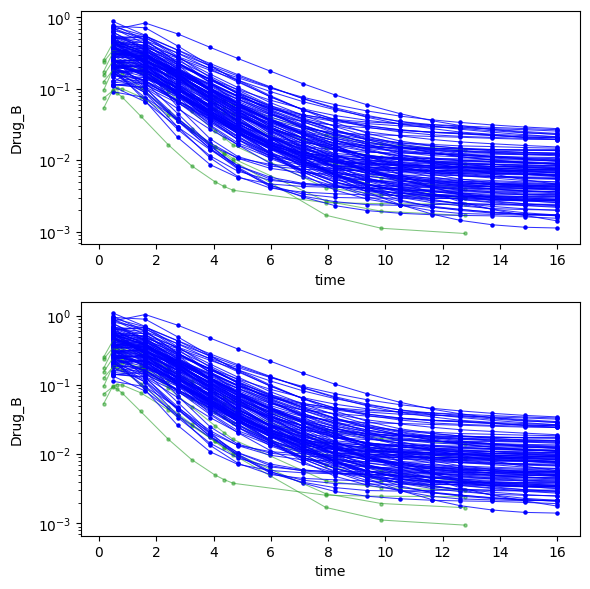

In [6]:
# Sample experiment: dosing_list from samples --------------------------------
dosing_list_sampled_studies = dm.generate_synthetic_study_experiment_list(
    n_targets=N_TARGETS,
    n_dosings=N_DOSINGS,
    dosing_mode="dosing_list",
    dosing_list_generation="dosing_from_samples",
)

print(
    f"Returned {len(dosing_list_sampled_studies)} studies for dosing_list "
    "with dosing_from_samples"
)
print("Metadata per realization:")
for study in dosing_list_sampled_studies:
    pprint(study["meta_data"])

_ = plot_list_list_study_json(
    studies=[dosing_list_sampled_studies],
    number_of_rows=None,
    number_of_columns=None,
    log_scale=True,
    plot_kwargs={"figure_size": (6, 6)},
)


# Dosing List From Range

Returned 2 studies for dosing_list with dosing_from_range over (-1.0, 1.0)
Metadata per realization:
{'dosing_mode': 'dosing_list',
 'dosing_realization_index': '0',
 'study_name': 'sample_experiment_Drug_B_dosing_list_0',
 'substance_name': 'Drug_B'}
{'dosing_mode': 'dosing_list',
 'dosing_realization_index': '1',
 'study_name': 'sample_experiment_Drug_B_dosing_list_1',
 'substance_name': 'Drug_B'}


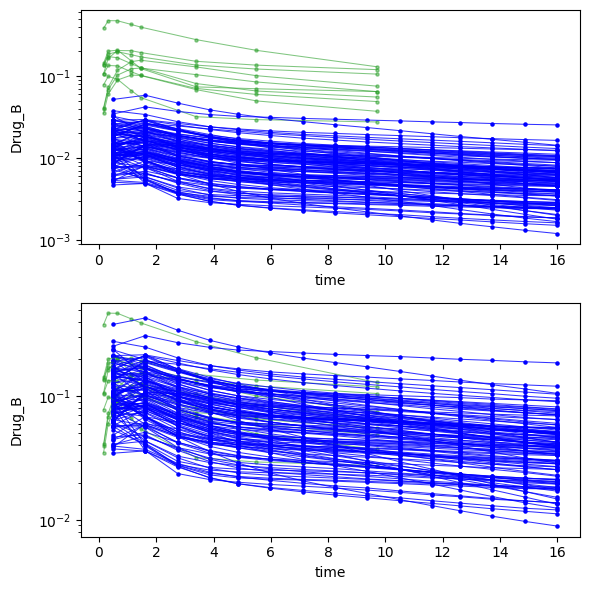

In [7]:
# Sample experiment: dosing_list from range ----------------------------------
LOGDOSE_RANGE = (-1.0, 1.0)

dosing_list_range_studies = dm.generate_synthetic_study_experiment_list(
    n_targets=N_TARGETS,
    n_dosings=N_DOSINGS,
    dosing_mode="dosing_list",
    dosing_list_generation="dosing_from_range",
    logdose_range=LOGDOSE_RANGE,
)

print(
    f"Returned {len(dosing_list_range_studies)} studies for dosing_list "
    f"with dosing_from_range over {LOGDOSE_RANGE}"
)
print("Metadata per realization:")
for study in dosing_list_range_studies:
    pprint(study["meta_data"])

_ = plot_list_list_study_json(
    studies=[dosing_list_range_studies],
    number_of_rows=None,
    number_of_columns=None,
    log_scale=True,
    plot_kwargs={"figure_size": (6, 6)},
)


# Diverse Dosing

Returned 1 study for diverse_dosing
{'dosing_mode': 'diverse_dosing',
 'dosing_realization_index': '0',
 'study_name': 'sample_experiment_Drug_A_diverse_dosing_0',
 'substance_name': 'Drug_A'}


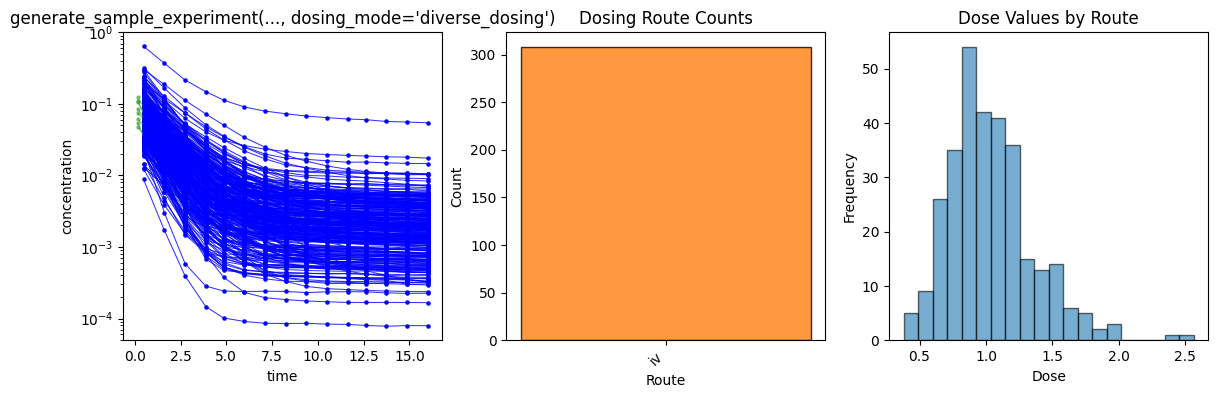

In [27]:
# DIVERSE DOSING CELL

%matplotlib inline
N_TARGETS = 300
N_DOSINGS = 1

# Sample experiment: diverse_dosing -------------------------------------------
diverse_dosing_studies = dm.generate_synthetic_study_experiment_list(
    n_targets=N_TARGETS,
    n_dosings=N_DOSINGS,
    dosing_mode="diverse_dosing",
)

print(f"Returned {len(diverse_dosing_studies)} study for diverse_dosing")
pprint(diverse_dosing_studies[0]["meta_data"])


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
_ = plot_study_json_with_dosing_histograms(
    diverse_dosing_studies[0],
    axes=axes,
    log_scale=True,
)
axes[0].set_title("generate_sample_experiment(..., dosing_mode='diverse_dosing')")
plt.show()


# Datamodule call

Returned 2 databatches from the loader
Permutation 0: context_obs=(2, 10, 15, 1), target_obs=(2, 40, 15, 1), study_names=['sample_experiment_Drug_B_repeated_dosing_0', 'sample_experiment_Drug_B_repeated_dosing_0']
Permutation 1: context_obs=(2, 10, 15, 1), target_obs=(2, 40, 15, 1), study_names=['sample_experiment_Drug_B_repeated_dosing_1', 'sample_experiment_Drug_B_repeated_dosing_1']


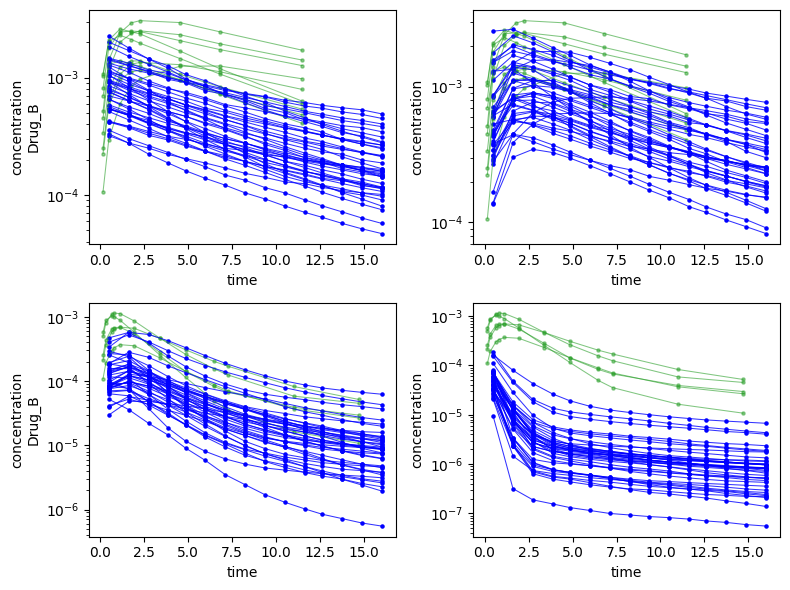

In [ ]:
# Datamodule helper: synthetic experiment dataloader ---------------------------
N_TARGETS = 40
N_DOSINGS = 2
DATASET_SIZE = 3

loader = dm.get_synthetic_experiment_dataloader(
    n_targets=N_TARGETS,
    n_dosings=N_DOSINGS,
    dosing_mode="repeated_dosing",
    dataset_size=DATASET_SIZE,
)

synthetic_batch_list = next(iter(loader))
print(f"Returned {len(synthetic_batch_list)} databatches from the loader")

for p, batch in enumerate(synthetic_batch_list):
    print(
        f"Permutation {p}: context_obs={tuple(batch.context_obs.shape)}, "
        f"target_obs={tuple(batch.target_obs.shape)}, "
        f"study_names={batch.study_name}"
    )

_ = plot_list_aicme_databatch(
    synthetic_batch_list,
    number_of_rows=2,
    number_of_columns=2,
    log_scale=True,
    file_name=None,
)
